# Hybrid Quantum-Classical Pneumonia Detection
**AI505 — Assignment 3**

## 1. Environment Setup
Installing PennyLane cleanly before any execution starts.

In [22]:
!pip install pennylane pennylane-lightning -q

## 2. Library Imports
Importing necessary PyTorch frameworks, PennyLane, and Sklearn metrics (including medical-specific metrics).

In [23]:
import os
import time
import random
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models

import pennylane as qml
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    f1_score, 
    precision_score,
    recall_score,
    confusion_matrix, 
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Configuration & Device Selection
Setting random seeds for exact reproducibility and hardware device selection (GPU if available).

In [24]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cuda


## 4. Dataset Configuration
Defining absolute Kaggle data paths and standard ImageNet geometric transformations.

In [25]:
DATA_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

## 5. Loading the Chest X-Ray Dataset
Constructing folder structures for processing the medical images.

In [26]:
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)

## 6. Balanced Subsampling Strategy
Filtering train labels strictly to perfectly balance Normal vs Pneumonia classes without excessive volume.

In [27]:
def get_balanced_subset(dataset, num_samples_per_class):
    indices = {0: [], 1: []}
    for idx, (_, label) in enumerate(dataset.samples):
        indices[label].append(idx)
    
    subset_indices = []
    for cls in [0, 1]:
        max_available = len(indices[cls])
        take_n = min(num_samples_per_class, max_available)
        
        sampled = random.sample(indices[cls], take_n)
        subset_indices.extend(sampled)
        
    return subset_indices

train_val_indices = get_balanced_subset(full_train_dataset, 720)
random.shuffle(train_val_indices)

train_subset = Subset(full_train_dataset, train_val_indices[:1200])
val_subset = Subset(full_train_dataset, train_val_indices[1200:1440])

## 7. Defining DataLoaders
Establishing tensor flow loaders with batches tailored appropriately for GPU processing.

In [28]:
batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

data_summary_df = pd.DataFrame({
    "Dataset Split": ["Training", "Validation", "Testing"],
    "Total Images": [len(train_subset), len(val_subset), len(test_dataset)]
})

display(Markdown("**Data loaded successfully. Split Summary:**"))
display(data_summary_df)

**Data loaded successfully. Split Summary:**

,Dataset Split,Total Images
0,Training,1200
1,Validation,240
2,Testing,624


## 8. Exploratory Data Analysis (EDA)
Analyzing class distributions to justify our subsampling strategy and visualizing patient X-Rays to inspect biological markers.

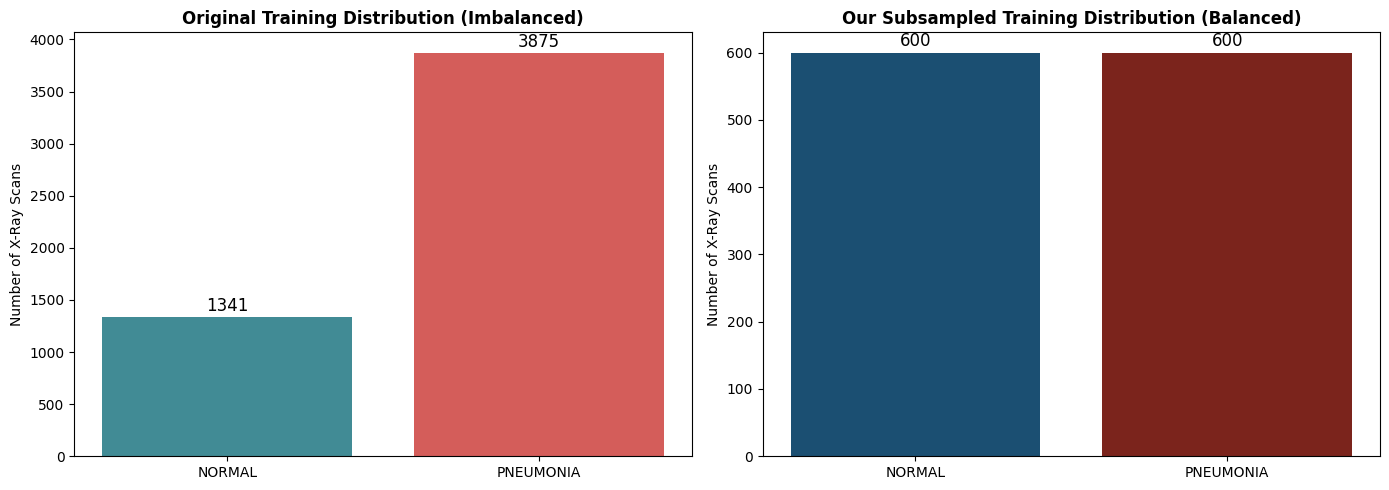

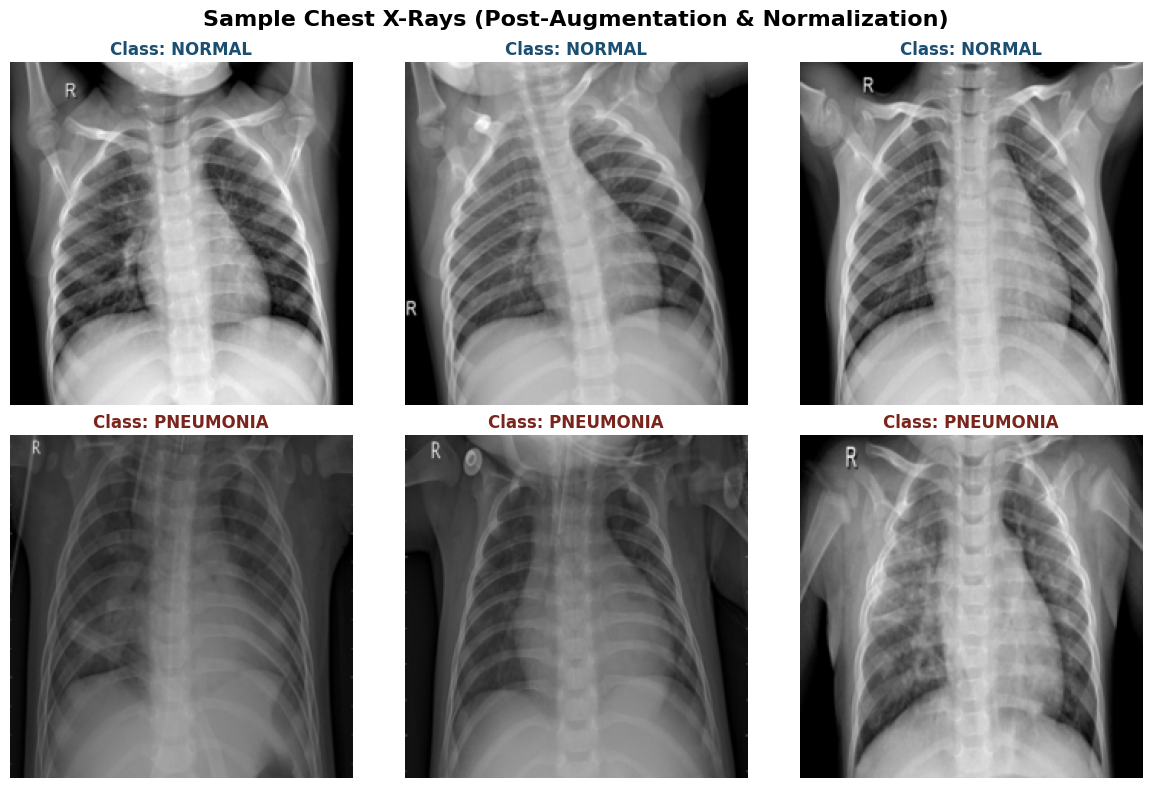

In [29]:
class_names = full_train_dataset.classes
original_counts = [full_train_dataset.targets.count(0), full_train_dataset.targets.count(1)]
balanced_counts = [600, 600] 

# PART 1: Distribution Analysis (The Justification for Subsampling)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(class_names, original_counts, color=['#418b95', '#d45d5a'])
axes[0].set_title("Original Training Distribution (Imbalanced)", fontweight='bold')
axes[0].set_ylabel("Number of X-Ray Scans")
for i, v in enumerate(original_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

axes[1].bar(class_names, balanced_counts, color=['#1b4f72', '#7b241c'])
axes[1].set_title("Our Subsampled Training Distribution (Balanced)", fontweight='bold')
axes[1].set_ylabel("Number of X-Ray Scans")
for i, v in enumerate(balanced_counts):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# PART 2: Biological Visual Assessment 
normal_samples = []
pneumonia_samples = []

for inputs, labels in train_loader:
    for i in range(len(labels)):
        if labels[i] == 0 and len(normal_samples) < 3:
            normal_samples.append(inputs[i])
        elif labels[i] == 1 and len(pneumonia_samples) < 3:
            pneumonia_samples.append(inputs[i])
    if len(normal_samples) == 3 and len(pneumonia_samples) == 3:
        break

def denormalize(tensor):
    img = tensor.numpy().transpose((1, 2, 0))
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    axes[0, i].imshow(denormalize(normal_samples[i]))
    axes[0, i].set_title("Class: NORMAL", color='#1b4f72', fontweight='bold')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(denormalize(pneumonia_samples[i]))
    axes[1, i].set_title("Class: PNEUMONIA", color='#7b241c', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("Sample Chest X-Rays (Post-Augmentation & Normalization)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Training Helper Function
A PyTorch epoch loop handling backpropagation, validation early-stopping, and loss tracking.

In [30]:
def train_model(model, criterion, optimizer, num_epochs=20, patience=3):
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_subset)
        
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
        val_loss /= len(val_subset)
        time_elapsed = time.time() - start_time
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        
        print(f"Epoch {epoch+1:02d}/{num_epochs} "
              f"| Train Loss: {epoch_loss:.4f} "
              f"| Val Loss: {val_loss:.4f} "
              f"| Time: {time_elapsed:.1f}s")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered!")
                break

    model.load_state_dict(best_model_wts)
    return model, history

## 10. Evaluation Helper Function
Extracting rigorous medical test metrics: Accuracy, AUC, F1, Precision, Sensitivity (Recall), and Specificity.

In [31]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    eval_time_ms = ((time.time() - start_time) / len(loader.dataset)) * 1000
    
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels)
    preds_binary = (all_preds > 0.5).astype(int)
    
    # Standard Metrics
    acc = accuracy_score(all_labels, preds_binary)
    auc = roc_auc_score(all_labels, all_preds)
    f1 = f1_score(all_labels, preds_binary)
    cm = confusion_matrix(all_labels, preds_binary)
    
    # Advanced Medical Metrics
    precision = precision_score(all_labels, preds_binary, zero_division=0)
    recall = recall_score(all_labels, preds_binary, zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return acc, auc, f1, precision, recall, specificity, cm, all_preds, all_labels, eval_time_ms

## 11. Visualization Helper Function
A clean, reusable function to plot diagnostic tables, curves, and matrices efficiently.

In [32]:
def print_and_plot_diagnostics(acc, auc_score, f1, prec, rec, spec, exec_time, history, cm, model_name, cmap, c_train, c_val):
    # 1. Print Pandas Table
    df = pd.DataFrame({
        "Diagnostic Metric": [
            "Accuracy", "AUC-ROC", "F1-Score", 
            "Precision", "Sensitivity (Recall)", "Specificity", "Time (ms)"
        ],
        f"{model_name} Score": [
            f"{acc:.4f}", f"{auc_score:.4f}", f"{f1:.4f}", 
            f"{prec:.4f}", f"{rec:.4f}", f"{spec:.4f}", f"{exec_time:.2f}"
        ]
    })
    display(Markdown(f"### {model_name} Results Summary"))
    display(df)
    
    # 2. Plot Learning Curves and Confusion Matrix Side-by-Side
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    axes[0].plot(history['train_loss'], label='Train Loss', color=c_train, linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', color=c_val, linestyle='--', linewidth=2)
    axes[0].set_title(f'{model_name} Learning Curve')
    axes[0].set_xlabel('Epochs'), axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[1], cbar=False)
    axes[1].set_title(f'{model_name} Confusion Matrix')
    axes[1].set_xlabel('Predicted Label'), axes[1].set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()

---
# PART A: Classical Baseline Phase

## 12. Baseline Model Architecture
Building a classical pre-trained ResNet-18, securely freezing features, and placing a binary classifier tail.

In [33]:
baseline_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in baseline_model.parameters():
    param.requires_grad = False

num_ftrs = baseline_model.fc.in_features
baseline_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 1),
    nn.Sigmoid()
)
baseline_model = baseline_model.to(device)

## 13. Baseline Model Training
Executing standard classical training up to a 20 epoch boundary limit.

In [34]:
criterion = nn.BCELoss()
optimizer_base = optim.Adam(baseline_model.fc.parameters(), lr=0.001)

print("Training Classical Baseline...")
baseline_model, history_b = train_model(baseline_model, criterion, optimizer_base, num_epochs=20, patience=3)

Training Classical Baseline...
Epoch 01/20 | Train Loss: 0.5284 | Val Loss: 0.4669 | Time: 31.5s
Epoch 02/20 | Train Loss: 0.3254 | Val Loss: 0.2991 | Time: 31.7s
Epoch 03/20 | Train Loss: 0.2585 | Val Loss: 0.2638 | Time: 31.7s
Epoch 04/20 | Train Loss: 0.2361 | Val Loss: 0.2428 | Time: 31.8s
Epoch 05/20 | Train Loss: 0.2313 | Val Loss: 0.2325 | Time: 31.8s
Epoch 06/20 | Train Loss: 0.2049 | Val Loss: 0.2221 | Time: 31.6s
Epoch 07/20 | Train Loss: 0.2116 | Val Loss: 0.2185 | Time: 32.2s
Epoch 08/20 | Train Loss: 0.1937 | Val Loss: 0.2155 | Time: 31.4s
Epoch 09/20 | Train Loss: 0.1937 | Val Loss: 0.2038 | Time: 31.9s
Epoch 10/20 | Train Loss: 0.1886 | Val Loss: 0.2022 | Time: 31.4s
Epoch 11/20 | Train Loss: 0.1731 | Val Loss: 0.1970 | Time: 31.5s
Epoch 12/20 | Train Loss: 0.1743 | Val Loss: 0.2056 | Time: 31.4s
Epoch 13/20 | Train Loss: 0.1736 | Val Loss: 0.1866 | Time: 31.2s
Epoch 14/20 | Train Loss: 0.1562 | Val Loss: 0.1842 | Time: 31.4s
Epoch 15/20 | Train Loss: 0.1516 | Val Loss: 

## 14. Baseline Evaluation & Visual Results
Outputting the precise testing metrics, Learning Curves, and Confusion Matrix specifically for the baseline.

### Baseline Results Summary

,Diagnostic Metric,Baseline Score
0,Accuracy,0.8446
1,AUC-ROC,0.9467
2,F1-Score,0.8849
3,Precision,0.8234
4,Sensitivity (Recall),0.9564
5,Specificity,0.6581
6,Time (ms),23.28


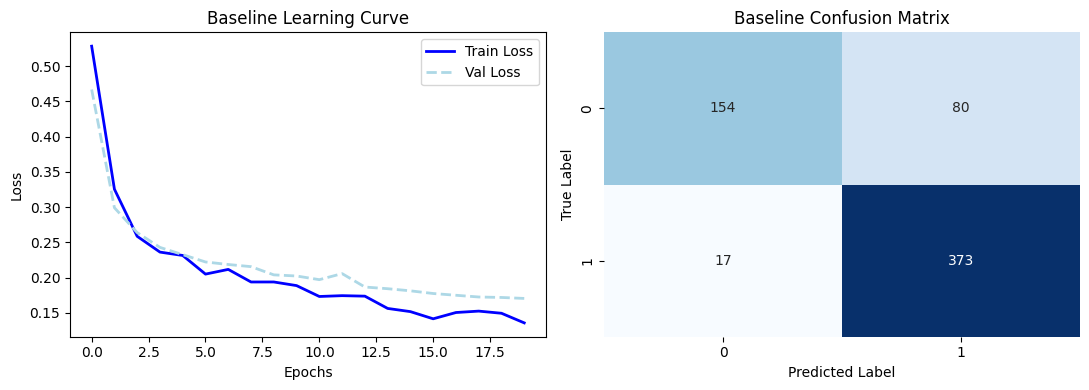

In [35]:
acc_b, auc_b, f1_b, prec_b, rec_b, spec_b, cm_b, preds_b, labels_b, time_b = evaluate_model(baseline_model, test_loader)

print_and_plot_diagnostics(
    acc_b, auc_b, f1_b, prec_b, rec_b, spec_b, time_b, history_b, cm_b, 
    model_name="Baseline", cmap="Blues", c_train="blue", c_val="lightblue"
)

---
# PART B: Hybrid Quantum Phase

## 15. Variational Quantum Circuit (VQC) Definition
Building a concise, isolated PennyLane NISQ-friendly circuit operating across 4 qubits directly.

In [39]:
n_qubits = 4
qml_device = "default.qubit"
dev = qml.device(qml_device, wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

## 16. Hybrid Model Architecture Integration
A custom module connecting 512 backbone dimensions to downscaled 4 dimensions passed logically into the VQC component.

In [42]:
class HybridModel(nn.Module):
    def __init__(self, resnet, quantum_circuit, n_qubits, n_layers=2):
        super(HybridModel, self).__init__()
        
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.dense = nn.Linear(512, n_qubits)
        self.q_params = nn.Parameter(torch.randn(n_layers, n_qubits))
        self.qc = quantum_circuit
        
    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
            
        x = x.view(x.size(0), -1)
        x = self.dense(x)
        x = torch.tanh(x) * torch.pi 
        
        # Safely bridge GPU data to CPU purely for the QNode execution
        x_cpu = x.to('cpu')
        q_params_cpu = self.q_params.to('cpu')
        
        q_out = torch.empty(x.size(0), device=x.device)
        for i in range(x.size(0)):
            res = self.qc(x_cpu[i], q_params_cpu)
            q_out[i] = res.to(x.device)
            
        q_out = q_out.unsqueeze(1)
        return torch.sigmoid(q_out)

resnet_clone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet_clone.parameters():
    param.requires_grad = False
    
hybrid_model = HybridModel(resnet_clone, quantum_circuit, n_qubits=n_qubits).to(device)

## 17. Hybrid Model Training
Integrating a slightly higher learning rate explicitly for resolving the unique quantum parameterized weights.

In [43]:
optimizer_hybrid = optim.Adam([
    {'params': hybrid_model.dense.parameters(), 'lr': 0.001},
    {'params': hybrid_model.q_params, 'lr': 0.005}
])

print("Training Hybrid Quantum Model...")
hybrid_model, history_h = train_model(hybrid_model, criterion, optimizer_hybrid, num_epochs=20, patience=3)

Training Hybrid Quantum Model...
Epoch 01/20 | Train Loss: 0.6383 | Val Loss: 0.6834 | Time: 51.4s
Epoch 02/20 | Train Loss: 0.5802 | Val Loss: 0.5551 | Time: 44.6s
Epoch 03/20 | Train Loss: 0.5244 | Val Loss: 0.5025 | Time: 44.7s
Epoch 04/20 | Train Loss: 0.4830 | Val Loss: 0.4680 | Time: 45.2s
Epoch 05/20 | Train Loss: 0.4628 | Val Loss: 0.4892 | Time: 45.1s
Epoch 06/20 | Train Loss: 0.4597 | Val Loss: 0.4403 | Time: 44.7s
Epoch 07/20 | Train Loss: 0.4204 | Val Loss: 0.4548 | Time: 44.6s
Epoch 08/20 | Train Loss: 0.4352 | Val Loss: 0.4477 | Time: 44.1s
Epoch 09/20 | Train Loss: 0.4380 | Val Loss: 0.4364 | Time: 44.7s
Epoch 10/20 | Train Loss: 0.4174 | Val Loss: 0.4344 | Time: 44.1s
Epoch 11/20 | Train Loss: 0.4011 | Val Loss: 0.4296 | Time: 44.5s
Epoch 12/20 | Train Loss: 0.4044 | Val Loss: 0.4235 | Time: 44.4s
Epoch 13/20 | Train Loss: 0.4209 | Val Loss: 0.4211 | Time: 44.6s
Epoch 14/20 | Train Loss: 0.3933 | Val Loss: 0.4172 | Time: 44.7s
Epoch 15/20 | Train Loss: 0.3948 | Val Loss

## 18. Hybrid Model Evaluation & Visual Results
Outputting the medical testing metrics, Learning Curves, and Confusion Matrix specifically for the quantum hybrid.

### Hybrid Results Summary

,Diagnostic Metric,Hybrid Score
0,Accuracy,0.8381
1,AUC-ROC,0.9199
2,F1-Score,0.8802
3,Precision,0.8190
4,Sensitivity (Recall),0.9513
5,Specificity,0.6496
6,Time (ms),22.31


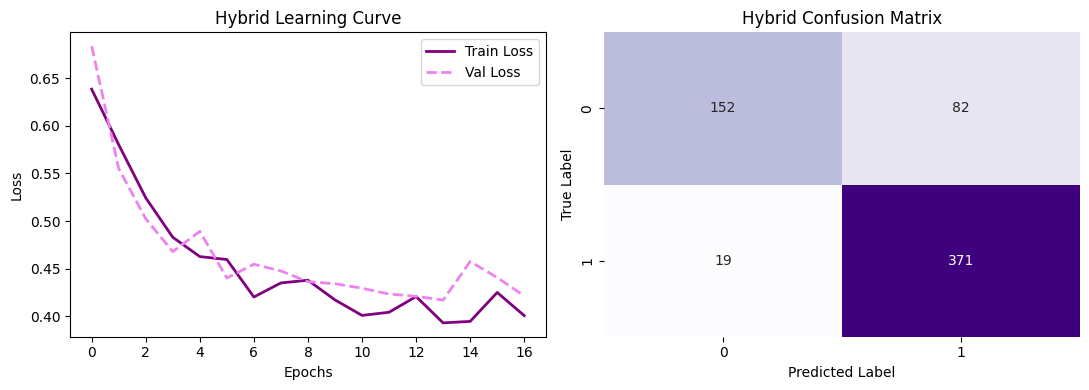

In [44]:
acc_h, auc_h, f1_h, prec_h, rec_h, spec_h, cm_h, preds_h, labels_h, time_h = evaluate_model(hybrid_model, test_loader)

print_and_plot_diagnostics(
    acc_h, auc_h, f1_h, prec_h, rec_h, spec_h, time_h, history_h, cm_h, 
    model_name="Hybrid", cmap="Purples", c_train="purple", c_val="violet"
)

---
# PART C: Final Comparative Analysis

## 19. Comparative Medical Diagnostics Table
Tracking relative classification metrics (Accuracy, AUC, F1, Sensitivity, Specificity) side by side.

In [45]:
results_df = pd.DataFrame({
    "Diagnostic Metric": [
        "Accuracy", "AUC-ROC", "F1-Score", 
        "Precision", "Sensitivity (Recall)", "Specificity", "Overhead (ms)"
    ],
    "Classical Baseline": [
        f"{acc_b:.4f}", f"{auc_b:.4f}", f"{f1_b:.4f}", 
        f"{prec_b:.4f}", f"{rec_b:.4f}", f"{spec_b:.4f}", f"{time_b:.2f}"
    ],
    "Hybrid Quantum": [
        f"{acc_h:.4f}", f"{auc_h:.4f}", f"{f1_h:.4f}", 
        f"{prec_h:.4f}", f"{rec_h:.4f}", f"{spec_h:.4f}", f"{time_h:.2f}"
    ]
})

display(Markdown("### Final Comparative Diagnostics"))
display(results_df)

### Final Comparative Diagnostics

,Diagnostic Metric,Classical Baseline,Hybrid Quantum
0,Accuracy,0.8446,0.8381
1,AUC-ROC,0.9467,0.9199
2,F1-Score,0.8849,0.8802
3,Precision,0.8234,0.8190
4,Sensitivity (Recall),0.9564,0.9513
5,Specificity,0.6581,0.6496
6,Overhead (ms),23.28,22.31


## 20. Comparative ROC Curve Overlay
Highlighting area under thresholds via comparative lines evaluating both models concurrently.

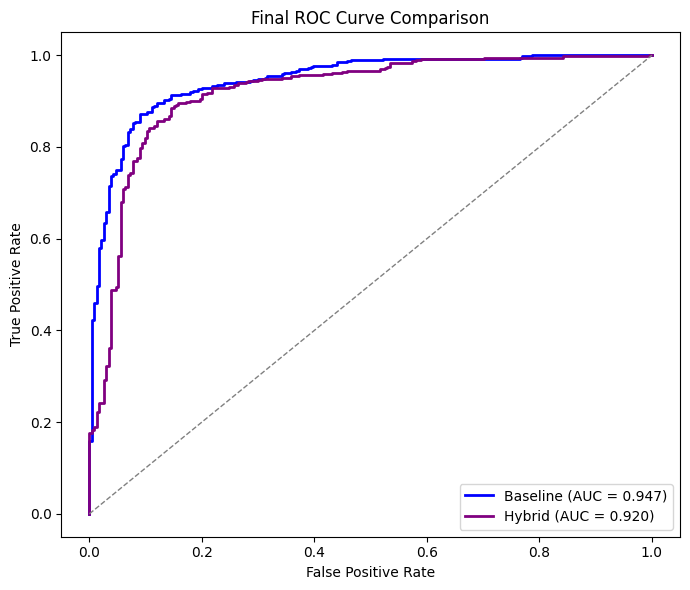

In [46]:
plt.figure(figsize=(7, 6))

fpr_b, tpr_b, _ = roc_curve(labels_b, preds_b)
fpr_h, tpr_h, _ = roc_curve(labels_h, preds_h)

plt.plot(fpr_b, tpr_b, color='blue', lw=2, label=f'Baseline (AUC = {auc_b:.3f})')
plt.plot(fpr_h, tpr_h, color='purple', lw=2, label=f'Hybrid (AUC = {auc_h:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.title('Final ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()